In [21]:
import sys

sys.path.append("../src")


import sys

sys.path.insert(0, "/Users/bohaoli/Desktop/tuto/tuto_langchain/official/langchain-langgraph-langsmith/utils")

from utils import ppm, ppms, debug

<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🧠 Agents with Memory — 让 agent 记住你的偏好

**一句话定位**:**HITL 反馈不再白费** —— 用 LangGraph Store 把用户的每次反馈 **持久化** 成 profile,下次自动用上,assistant 越用越懂你。

</div>

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**📚 整门课的最后一块拼图**

| 模块             | 状态                                     |
| ---------------- | ---------------------------------------- |
| ✅ M2 Build      | router + agent 搭好                      |
| ✅ M3 Evaluate   | 用 LangSmith 测明白                      |
| ✅ M4 HITL       | 加 review 机制,人能干预                  |
| **➡️ M5 Memory** | **HITL 反馈持久化 → assistant 学习偏好** |

→ 没有 memory 的 HITL = 每次都要重复纠正同样的错误。**加上 memory = 越用越省心**。

</div>

![overview-img](img/overview_memory.png)


#### 🔐 加载环境变量


In [16]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

## 🧠 LangGraph 里的 Memory

### 🧵 Thread-Scoped vs 🌐 Across-Thread Memory

[LangGraph 的 memory](https://langchain-ai.github.io/langgraph/concepts/memory/) 有 **两种类型**,**互补**:

| 类型                    | 范围       | 存哪         | 例子                             |
| ----------------------- | ---------- | ------------ | -------------------------------- |
| **Thread-Scoped(短期)** | 单次会话内 | checkpointer | 当次对话历史、上传文件、检索结果 |
| **Across-Thread(长期)** | **跨会话** | **Store**    | 用户偏好、过往决策、积累的知识   |

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💡 类比 = RAM vs 硬盘**

- **Thread-Scoped** ≈ RAM:agent 在干当前任务时的工作记忆,断电就没了
- **Across-Thread** ≈ 硬盘:跨会话持久存的「人格画像」、长期偏好

后者让 agent **真正学习和适应**,而不是每次对话都从零开始。

</div>

![short-vs-long-term-memory](img/short-vs-long.png)

### 🗄️ Store —— 长期记忆的基础设施

[Store](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) 是这套架构的基础,提供 **灵活的数据库**,让 memory 能 **组织、检索、更新**。

**关键设计**:不管你用哪种 Store 实现,**接口都是统一的** —— agent 代码不变,**开发用内存版,生产用 Postgres** 无缝切换。

### 🛠️ Store 的 3 种实现

[LangGraph Store 有不同实现](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore),按 [部署方式](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options) 选:

| #     | 实现                                                                | 持久化                       | 用途                                                                                                               |
| ----- | ------------------------------------------------------------------- | ---------------------------- | ------------------------------------------------------------------------------------------------------------------ |
| **1** | `InMemoryStore`(`from langgraph.store.memory import InMemoryStore`) | ❌ 进程结束丢光              | Notebook 实验、快速测试。可配 [语义搜索](https://langchain-ai.github.io/langgraph/how-tos/memory/semantic-search/) |
| **2** | `langgraph dev` 本地开发                                            | ⚠️ pickle 到本地文件         | 类 `InMemoryStore` 但重启不丢。开发好用,生产不行                                                                   |
| **3** | **LangGraph Platform / 生产**                                       | ✅ **PostgreSQL + pgvector** | 完全持久、可备份、可扩展。默认余弦相似度,可自定义距离                                                              |

本课先用 `InMemoryStore` 在 notebook 里玩。


In [17]:
from langgraph.store.memory import InMemoryStore

in_memory_store = InMemoryStore()

### 🏷️ Namespace —— 用 tuple 给 memory 分类

Memory 用 **tuple 做 namespace** 来组织。

本例中 namespace 是 `(<user_id>, "memories")` —— 但 **namespace 想多长多长**,**可以代表任何东西**(不一定要绑用户)。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 设计意图**:tuple 像 **文件夹路径**,可以做层级 —— 例如 `("user_42", "calendar_prefs")` 和 `("user_42", "response_prefs")` 把同一个用户的不同偏好分开存。

</div>


In [18]:
user_id = "1"
namespace_for_memory = (user_id, "memories")

### 💾 写入 Memory —— `store.put`

用 `store.put` 方法把 memory **存进 namespace**:

| 参数        | 含义                             |
| ----------- | -------------------------------- |
| `namespace` | 上面定义的 tuple                 |
| `key`       | memory 的 **唯一 ID**(memory_id) |
| `value`     | memory **本身**(一个 dict)       |


In [19]:
import uuid

memory_id = str(uuid.uuid4())
memory = {"food_preference": "I like pizza"}
in_memory_store.put(namespace_for_memory, memory_id, memory)

### 🔍 读取 Memory —— `store.search`

用 `store.search` 读出 namespace 里的 memory,返回 **list**(**最新的在最后**)。

每个 memory 是 Python 的 `Item` 类:

| 属性                       | 含义                     |
| -------------------------- | ------------------------ |
| `value`                    | **最重要的**:你存的 dict |
| `key`                      | memory_id                |
| `namespace`                | 它所在的 namespace       |
| `created_at`, `updated_at` | 时间戳                   |

可以 `.dict()` 把它转成字典。


In [22]:
memories = in_memory_store.search(namespace_for_memory)
debug(memories[-1].dict())

╭─────────────────────────────────────────────────── 🧠 Debug ────────────────────────────────────────────────────╮
│ {                                                                                                               │
│   "namespace": [                                                                                                │
│     "1",                                                                                                        │
│     "memories"                                                                                                  │
│   ],                                                                                                            │
│   "key": "ddcf2c75-efd4-42ba-8bad-4ed40de9ab08",                                                                │
│   "value": {                                                                                                    │
│     "food_preference": "I like pizza"                                                                           │
│   },                                                                                                            │
│   "created_at": "2026-05-18T15:15:40.559249+00:00",                                                             │
│   "updated_at": "2026-05-18T15:15:40.559252+00:00",                                                             │
│   "score": null                                                                                                 │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 🧩 在 Graph 里用 Store

把 store 当参数传给 `.compile()`,然后整个图都能用:


In [23]:
# We need this because we want to enable threads (conversations)
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
# We need this because we want to enable across-thread memory
from langgraph.store.memory import InMemoryStore

in_memory_store = InMemoryStore()
# Compile the graph with the checkpointer and store
# graph = graph.compile(checkpointer=checkpointer, store=in_memory_store)

然后 store **在任何 node 都能访问**(像 checkpointer 一样)。

## 🔧 给 Assistant 加 Memory

把 HITL 版本的 graph 升级:**在用户给反馈时,把反馈写进 Store**。

![overview-img](img/HITL_flow_memory.png)

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💡 改动其实非常小**

我们之前已经有完整的 HITL 流程。加 memory 只需要 **在 interrupt handler 处理用户反馈时,顺手调用一个 `update_memory()` 函数**。

主流程不动,只在 4 个位置插入 memory 更新调用 —— 这是 LangGraph 「组件可叠加」哲学的体现。

</div>


In [24]:

%load_ext autoreload
%autoreload 2

from typing import Literal
from datetime import datetime
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.store.base import BaseStore
from langgraph.types import interrupt, Command
import sys
sys.path.append("../src")
from email_assistant.prompts import triage_system_prompt, triage_user_prompt, agent_system_prompt_hitl_memory, default_triage_instructions, default_background, default_response_preferences, default_cal_preferences, MEMORY_UPDATE_INSTRUCTIONS, MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT
from email_assistant.tools.default.prompt_templates import HITL_MEMORY_TOOLS_PROMPT
from email_assistant.schemas import State, RouterSchema, StateInput
from email_assistant.utils import parse_email, format_for_display, format_email_markdown

# Agent tools 
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
class Question(BaseModel):
      """Question to ask user."""
      content: str

@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool
    
# All tools available to the agent
tools = [
    write_email, 
    schedule_meeting, 
    check_calendar_availability, 
    Question, 
    Done
]

tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM for use with router / structured output
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

# Initialize the LLM, enforcing tool use (of any available tools) for agent
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="required")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 🧠 Memory 管理 —— 两个核心问题

我们目前的 graph 没有 **捕获** 用户反馈。

要做的事简单:**把反馈加到 Store**。

但要回答 **两个设计问题**:

| 问题                            | 本课答案                 |
| ------------------------------- | ------------------------ |
| **1. memory 怎么组织(schema)?** | 直接 **存字符串**(最简)  |
| **2. memory 怎么更新?**         | **LLM 改写**(下一节细讲) |

下面的函数:**从 Store 取出指定 namespace 的 memory(字符串),如果不存在就用 default 初始化**。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 3 个 namespace 对应 3 类偏好**

- `triage_preferences` —— 邮件分类偏好
- `cal_preferences` —— 日历偏好
- `response_preferences` —— 邮件回复风格偏好

</div>


In [25]:
from rich.markdown import Markdown

Markdown(default_triage_instructions)

Emails that are not worth responding to:                                                                           

 • Marketing newsletters and promotional emails                                                                    
 • Spam or suspicious emails                                                                                       
 • CC'd on FYI threads with no direct questions                                                                    

There are also other things that should be known about, but don't require an email response. For these, you should 
notify (using the notify response). Examples of this include:                                                      

 • Team member out sick or on vacation                                                                             
 • Build system notifications or deployments                                                                       
 • Project status updates without action items                                                                     
 • Important company announcements                                                                                 
 • FYI emails that contain relevant information for current projects                                               
 • HR Department deadline reminders                                                                                
 • Subscription status / renewal reminders                                                                         
 • GitHub notifications                                                                                            

Emails that are worth responding to:                                                                               

 • Direct questions from team members requiring expertise                                                          
 • Meeting requests requiring confirmation                                                                         
 • Critical bug reports related to team's projects                                                                 
 • Requests from management requiring acknowledgment                                                               
 • Client inquiries about project status or features                                                               
 • Technical questions about documentation, code, or APIs (especially questions about missing endpoints or         
   features)                                                                                                       
 • Personal reminders related to family (wife / daughter)                                                          
 • Personal reminder related to self-care (doctor appointments, etc)

In [26]:
Markdown(default_cal_preferences)

30 minute meetings are preferred, but 15 minute meetings are also acceptable.

In [27]:
Markdown(default_response_preferences)

Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and  
reference the deadline in your response.                                                                           

When responding to technical questions that require investigation:                                                 

 • Clearly state whether you will investigate or who you will ask                                                  
 • Provide an estimated timeline for when you'll have more information or complete the task                        

When responding to event or conference invitations:                                                                

 • Always acknowledge any mentioned deadlines (particularly registration deadlines)                                
 • If workshops or specific topics are mentioned, ask for more specific details about them                         
 • If discounts (group or early bird) are mentioned, explicitly request information about them                     
 • Don't commit                                                                                                    

When responding to collaboration or project-related requests:                                                      

 • Acknowledge any existing work or materials mentioned (drafts, slides, documents, etc.)                          
 • Explicitly mention reviewing these materials before or during the meeting                                       
 • When scheduling meetings, clearly state the specific day, date, and time proposed                               

When responding to meeting scheduling requests:                                                                    

 • If times are proposed, verify calendar availability for all time slots mentioned in the original email and then 
   commit to one of the proposed times based on your availability by scheduling the meeting. Or, say you can't make
   it at the time proposed.                                                                                        
 • If no times are proposed, then check your calendar for availability and propose multiple time options when      
   available instead of selecting just one.                                                                        
 • Mention the meeting duration in your response to confirm you've noted it correctly.                             
 • Reference the meeting's purpose in your response.

In [28]:
def get_memory(store, namespace, default_content=None):
    """Get memory from the store or initialize with default if it doesn't exist.

    Args:
        store: LangGraph BaseStore instance to search for existing memory
        namespace: Tuple defining the memory namespace, e.g. ("email_assistant", "triage_preferences")
        default_content: Default content to use if memory doesn't exist

    Returns:
        str: The content of the memory profile, either from existing memory or the default
    """
    # Search for existing memory with namespace and key
    user_preferences = store.get(namespace, "user_preferences")

    # If memory exists, return its content (the value)
    if user_preferences:
        return user_preferences.value

    # If memory doesn't exist, add it to the store and return the default content
    else:
        # Namespace, key, value
        store.put(namespace, "user_preferences", default_content)
        user_preferences = default_content

    # Return the default content
    return user_preferences

### 🔄 怎么更新 memory? —— 让 LLM 改写

更新 memory 时,我们用 [GPT-4.1 prompting guide](https://cookbook.openai.com/examples/gpt4-1_prompting_guide) 的几个技巧:

| 技巧                 | 含义                                             |
| -------------------- | ------------------------------------------------ |
| **首尾重复关键指令** | 长 prompt 中关键指令重复在首尾,LLM 更可能 follow |
| **指令清晰、明确**   | 不要含糊措辞                                     |
| **XML 分隔结构**     | 用 `<section>` tag 划分                          |
| **提供示例**         | few-shot 例子                                    |

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 设计核心:用 LLM 把「**自然语言反馈**」翻译成「**结构化偏好**」**

用户给反馈:「会议短一点,下午」(自然语言)

→ LLM 读: 现有 memory + 这次反馈 + message 上下文

→ LLM 输出:新版 memory(整合现有 + 新偏好)

→ 写回 Store

整个 memory 系统 = **LLM 做了 "diff & merge"**,我们提供 schema 和 prompt 指导。

</div>

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

**🆕 2026 年提示**:这种「LLM 自己管 memory」的模式是当前 ambient agent 的事实标准。

更进阶的库:[**LangMem**](https://langchain-ai.github.io/langmem/) 已经做了完整封装(语义搜索、TTL、内存合并策略等),生产可以直接用。

</div>


In [29]:
Markdown(MEMORY_UPDATE_INSTRUCTIONS)

Role and Objective                                                 

You are a memory profile manager for an email assistant agent that selectively updates user preferences based on   
feedback messages from human-in-the-loop interactions with the email assistant.                                    

                                                   Instructions                                                    

 • NEVER overwrite the entire memory profile                                                                       
 • ONLY make targeted additions of new information                                                                 
 • ONLY update specific facts that are directly contradicted by feedback messages                                  
 • PRESERVE all other existing information in the profile                                                          
 • Format the profile consistently with the original style                                                         
 • Generate the profile as a string                                                                                

                                                  Reasoning Steps                                                  

 1 Analyze the current memory profile structure and content                                                        
 2 Review feedback messages from human-in-the-loop interactions                                                    
 3 Extract relevant user preferences from these feedback messages (such as edits to emails/calendar invites,       
   explicit feedback on assistant performance, user decisions to ignore certain emails)                            
 4 Compare new information against existing profile                                                                
 5 Identify only specific facts to add or update                                                                   
 6 Preserve all other existing information                                                                         
 7 Output the complete updated profile                                                                             

                                                      Example                                                      

<memory_profile> RESPOND:                                                                                          

 • wife                                                                                                            
 • specific questions                                                                                              
 • system admin notifications NOTIFY:                                                                              
 • meeting invites IGNORE:                                                                                         
 • marketing emails                                                                                                
 • company-wide announcements                                                                                      
 • messages meant for other teams </memory_profile>                                                                

<user_messages> "The assistant shouldn't have responded to that system admin notification." </user_messages>       

<updated_profile> RESPOND:                                                                                         

 • wife                                                                                                            
 • specific questions NOTIFY:                                                                                      
 • meeting invites                                                                                                 
 • system admin notifications IGNORE:                                                                              
 • marketing emails                                                                          

In [30]:
Markdown(MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT)

Remember:                                                                                                          

 • NEVER overwrite the entire memory profile                                                                       
 • ONLY make targeted additions of new information                                                                 
 • ONLY update specific facts that are directly contradicted by feedback messages                                  
 • PRESERVE all other existing information in the profile                                                          
 • Format the profile consistently with the original style                                                         
 • Generate the profile as a string

In [31]:
class UserPreferences(BaseModel):
    """Updated user preferences based on user's feedback."""

    chain_of_thought: str = Field(description="Reasoning about which user preferences need to add / update if required")
    user_preferences: str = Field(description="Updated user preferences")


def update_memory(store, namespace, messages):
    """Update memory profile in the store.

    Args:
        store: LangGraph BaseStore instance to update memory
        namespace: Tuple defining the memory namespace, e.g. ("email_assistant", "triage_preferences")
        messages: List of messages to update the memory with
    """

    # Get the existing memory
    user_preferences = store.get(namespace, "user_preferences")

    # Update the memory
    llm = init_chat_model("openai:gpt-4.1", temperature=0.0).with_structured_output(UserPreferences)
    result = llm.invoke(
        [
            {
                "role": "system",
                "content": MEMORY_UPDATE_INSTRUCTIONS.format(
                    current_profile=user_preferences.value, namespace=namespace
                ),
            },
        ]
        + messages
    )

    # Save the updated memory to the store
    store.put(namespace, "user_preferences", result.user_preferences)

### 🎯 Triage Router(几乎不变)

triage 路由跟之前一样,**只加一处**:把 memory 里的 triage preferences 喂进 prompt。


In [32]:
def triage_router(
    state: State, store: BaseStore
) -> Command[Literal["triage_interrupt_handler", "response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore.

    The triage step prevents the assistant from wasting time on:
    - Marketing emails and spam
    - Company-wide announcements
    - Messages meant for other teams
    """
    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])
    user_prompt = triage_user_prompt.format(author=author, to=to, subject=subject, email_thread=email_thread)

    # Create email markdown for Agent Inbox in case of notification
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Search for existing triage_preferences memory
    triage_instructions = get_memory(store, ("email_assistant", "triage_preferences"), default_triage_instructions)

    # Format system prompt with background and triage instructions
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=triage_instructions,
    )

    # Run the router LLM
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )

    # Decision
    classification = result.classification

    # Process the classification decision
    if classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        # Next node
        goto = "response_agent"
        # Update the state
        update = {
            "classification_decision": result.classification,
            "messages": [{"role": "user", "content": f"Respond to the email: {email_markdown}"}],
        }

    elif classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")

        # Next node
        goto = END
        # Update the state
        update = {
            "classification_decision": classification,
        }

    elif classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")

        # Next node
        goto = "triage_interrupt_handler"
        # Update the state
        update = {
            "classification_decision": classification,
        }

    else:
        raise ValueError(f"Invalid classification: {classification}")

    return Command(goto=goto, update=update)

### 🚦 Interrupt Handler 的小改动

只需要在 **用户给反馈时** 加一个调用 —— 把反馈写进 memory store。其他逻辑不动。


In [33]:
def triage_interrupt_handler(state: State, store: BaseStore) -> Command[Literal["response_agent", "__end__"]]:
    """Handles interrupts from the triage step"""

    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])

    # Create email markdown for Agent Inbox in case of notification
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Create messages
    messages = [{"role": "user", "content": f"Email to notify user about: {email_markdown}"}]

    # Create interrupt for Agent Inbox
    request = {
        "action_request": {"action": f"Email Assistant: {state['classification_decision']}", "args": {}},
        "config": {
            "allow_ignore": True,
            "allow_respond": True,
            "allow_edit": False,
            "allow_accept": False,
        },
        # Email to show in Agent Inbox
        "description": email_markdown,
    }

    # Send to Agent Inbox and wait for response
    response = interrupt([request])[0]

    # If user provides feedback, go to response agent and use feedback to respond to email
    if response["type"] == "response":
        # Add feedback to messages
        user_input = response["args"]
        messages.append(
            {"role": "user", "content": f"User wants to reply to the email. Use this feedback to respond: {user_input}"}
        )
        # This is new: update triage_preferences with feedback
        update_memory(
            store,
            ("email_assistant", "triage_preferences"),
            [
                {
                    "role": "user",
                    "content": f"The user decided to respond to the email, so update the triage preferences to capture this.",
                }
            ]
            + messages,
        )

        goto = "response_agent"

    # If user ignores email, go to END
    elif response["type"] == "ignore":
        # Make note of the user's decision to ignore the email
        messages.append(
            {
                "role": "user",
                "content": f"The user decided to ignore the email even though it was classified as notify. Update triage preferences to capture this.",
            }
        )
        # This is new: triage_preferences with feedback
        update_memory(store, ("email_assistant", "triage_preferences"), messages)
        goto = END

    # Catch all other responses
    else:
        raise ValueError(f"Invalid response: {response}")

    # Update the state
    update = {
        "messages": messages,
    }

    return Command(goto=goto, update=update)

### 🧠 把 Memory 注入 LLM Responses

Memory manager 设好后,**生成回复时也要把 memory 喂进 prompt** —— 否则存了等于没存。


In [34]:
def llm_call(state: State, store: BaseStore):
    """LLM decides whether to call a tool or not"""

    # Search for existing cal_preferences memory
    cal_preferences = get_memory(store, ("email_assistant", "cal_preferences"), default_cal_preferences)

    # Search for existing response_preferences memory
    response_preferences = get_memory(store, ("email_assistant", "response_preferences"), default_response_preferences)

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    {
                        "role": "system",
                        "content": agent_system_prompt_hitl_memory.format(
                            tools_prompt=HITL_MEMORY_TOOLS_PROMPT,
                            background=default_background,
                            response_preferences=response_preferences,
                            cal_preferences=cal_preferences,
                        ),
                    }
                ]
                + state["messages"]
            )
        ]
    }

### 🚦 Interrupt Handler 里集成 Memory

跟前面一样,在 interrupt handler 里 **调用 memory 更新** —— 用户每给反馈,memory 同步更新。


In [35]:
def interrupt_handler(state: State, store: BaseStore) -> Command[Literal["llm_call", "__end__"]]:
    """Creates an interrupt for human review of tool calls"""

    # Store messages
    result = []

    # Go to the LLM call node next
    goto = "llm_call"

    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:

        # Allowed tools for HITL
        hitl_tools = ["write_email", "schedule_meeting", "Question"]

        # If tool is not in our HITL list, execute it directly without interruption
        if tool_call["name"] not in hitl_tools:

            # Execute tool without interruption
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
            continue

        # Get original email from email_input in state
        email_input = state["email_input"]
        author, to, subject, email_thread = parse_email(email_input)
        original_email_markdown = format_email_markdown(subject, author, to, email_thread)

        # Format tool call for display and prepend the original email
        tool_display = format_for_display(tool_call)
        description = original_email_markdown + tool_display

        # Configure what actions are allowed in Agent Inbox
        if tool_call["name"] == "write_email":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "schedule_meeting":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "Question":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": False,
                "allow_accept": False,
            }
        else:
            raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Create the interrupt request
        request = {
            "action_request": {"action": tool_call["name"], "args": tool_call["args"]},
            "config": config,
            "description": description,
        }

        # Send to Agent Inbox and wait for response
        response = interrupt([request])[0]

        # Handle the responses
        if response["type"] == "accept":

            # Execute the tool with original args
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})

        elif response["type"] == "edit":

            # Tool selection
            tool = tools_by_name[tool_call["name"]]
            initial_tool_call = tool_call["args"]

            # Get edited args from Agent Inbox
            edited_args = response["args"]["args"]

            # Update the AI message's tool call with edited content (reference to the message in the state)
            ai_message = state["messages"][-1]  # Get the most recent message from the state
            current_id = tool_call["id"]  # Store the ID of the tool call being edited

            # Create a new list of tool calls by filtering out the one being edited and adding the updated version
            # This avoids modifying the original list directly (immutable approach)
            updated_tool_calls = [tc for tc in ai_message.tool_calls if tc["id"] != current_id] + [
                {"type": "tool_call", "name": tool_call["name"], "args": edited_args, "id": current_id}
            ]

            # Create a new copy of the message with updated tool calls rather than modifying the original
            # This ensures state immutability and prevents side effects in other parts of the code
            # When we update the messages state key ("messages": result), the add_messages reducer will
            # overwrite existing messages by id and we take advantage of this here to update the tool calls.
            result.append(ai_message.model_copy(update={"tool_calls": updated_tool_calls}))

            # Save feedback in memory and update the write_email tool call with the edited content from Agent Inbox
            if tool_call["name"] == "write_email":

                # Execute the tool with edited args
                observation = tool.invoke(edited_args)

                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "response_preferences"),
                    [
                        {
                            "role": "user",
                            "content": f"User edited the email response. Here is the initial email generated by the assistant: {initial_tool_call}. Here is the edited email: {edited_args}. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            # Save feedback in memory and update the schedule_meeting tool call with the edited content from Agent Inbox
            elif tool_call["name"] == "schedule_meeting":

                # Execute the tool with edited args
                observation = tool.invoke(edited_args)

                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "cal_preferences"),
                    [
                        {
                            "role": "user",
                            "content": f"User edited the calendar invitation. Here is the initial calendar invitation generated by the assistant: {initial_tool_call}. Here is the edited calendar invitation: {edited_args}. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            # Catch all other tool calls
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "ignore":

            if tool_call["name"] == "write_email":
                # Don't execute the tool, and tell the agent how to proceed
                result.append(
                    {
                        "role": "tool",
                        "content": "User ignored this email draft. Ignore this email and end the workflow.",
                        "tool_call_id": tool_call["id"],
                    }
                )
                # Go to END
                goto = END
                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "triage_preferences"),
                    state["messages"]
                    + result
                    + [
                        {
                            "role": "user",
                            "content": f"The user ignored the email draft. That means they did not want to respond to the email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and tell the agent how to proceed
                result.append(
                    {
                        "role": "tool",
                        "content": "User ignored this calendar meeting draft. Ignore this email and end the workflow.",
                        "tool_call_id": tool_call["id"],
                    }
                )
                # Go to END
                goto = END
                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "triage_preferences"),
                    state["messages"]
                    + result
                    + [
                        {
                            "role": "user",
                            "content": f"The user ignored the calendar meeting draft. That means they did not want to schedule a meeting for this email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            elif tool_call["name"] == "Question":
                # Don't execute the tool, and tell the agent how to proceed
                result.append(
                    {
                        "role": "tool",
                        "content": "User ignored this question. Ignore this email and end the workflow.",
                        "tool_call_id": tool_call["id"],
                    }
                )
                # Go to END
                goto = END
                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "triage_preferences"),
                    state["messages"]
                    + result
                    + [
                        {
                            "role": "user",
                            "content": f"The user ignored the Question. That means they did not want to answer the question or deal with this email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "response":
            # User provided feedback
            user_feedback = response["args"]
            if tool_call["name"] == "write_email":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append(
                    {
                        "role": "tool",
                        "content": f"User gave feedback, which can we incorporate into the email. Feedback: {user_feedback}",
                        "tool_call_id": tool_call["id"],
                    }
                )
                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "response_preferences"),
                    state["messages"]
                    + result
                    + [
                        {
                            "role": "user",
                            "content": f"User gave feedback, which we can use to update the response preferences. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append(
                    {
                        "role": "tool",
                        "content": f"User gave feedback, which can we incorporate into the meeting request. Feedback: {user_feedback}",
                        "tool_call_id": tool_call["id"],
                    }
                )
                # This is new: update the memory
                update_memory(
                    store,
                    ("email_assistant", "cal_preferences"),
                    state["messages"]
                    + result
                    + [
                        {
                            "role": "user",
                            "content": f"User gave feedback, which we can use to update the calendar preferences. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}.",
                        }
                    ],
                )

            elif tool_call["name"] == "Question":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append(
                    {
                        "role": "tool",
                        "content": f"User answered the question, which can we can use for any follow up actions. Feedback: {user_feedback}",
                        "tool_call_id": tool_call["id"],
                    }
                )

            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

    # Update the state
    update = {
        "messages": result,
    }

    return Command(goto=goto, update=update)

### 🧩 剩下的部分跟 HITL 版完全一样


/var/folders/xx/ypnl5f2n0y7b48w_pgxyhqt80000gn/T/ipykernel_91024/3632558548.py:40: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  StateGraph(State, input=StateInput)


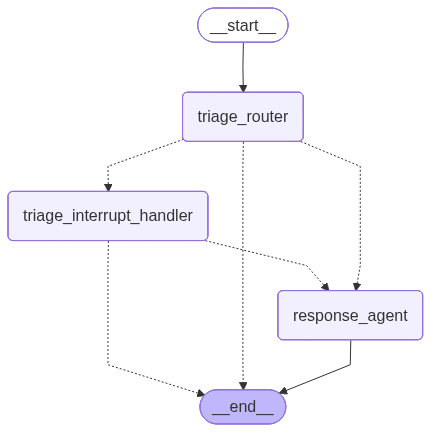

In [36]:
from email_assistant.utils import show_graph


# Conditional edge function
def should_continue(state: State, store: BaseStore) -> Literal["interrupt_handler", END]:
    """Route to tool handler, or end if Done tool called"""
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls:
            if tool_call["name"] == "Done":
                return END
            else:
                return "interrupt_handler"


# Build workflow
agent_builder = StateGraph(State)

# Add nodes - with store parameter
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("interrupt_handler", interrupt_handler)

# Add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "interrupt_handler": "interrupt_handler",
        END: END,
    },
)

# Compile the agent
response_agent = agent_builder.compile()

# Build overall workflow with store and checkpointer
overall_workflow = (
    StateGraph(State, input=StateInput)
    .add_node(triage_router)
    .add_node(triage_interrupt_handler)
    .add_node("response_agent", response_agent)
    .add_edge(START, "triage_router")
)

email_assistant = overall_workflow.compile()
show_graph(email_assistant)

## 🧪 测试带 memory 的 agent

把 memory 集成进 email assistant 后,**测试它怎么从反馈学习**。

### 🎯 三个测试要回答的问题

| #   | 问题                                   |
| --- | -------------------------------------- |
| 1   | 系统 **怎么捕获和存储** 用户偏好?      |
| 2   | 存储的偏好 **怎么影响未来决策**?       |
| 3   | 哪种交互模式 **触发哪种 memory 更新**? |

### 🛠️ 辅助函数

先写一个 helper 函数显示 memory 内容,方便追踪它的演变。


In [37]:
import uuid
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langgraph.store.memory import InMemoryStore


# Helper function to display memory content
def display_memory_content(store, namespace=None):
    # Display current memory content for all namespaces
    print("\n======= CURRENT MEMORY CONTENT =======")
    if namespace:
        memory = store.get(namespace, "user_preferences")
        if memory:
            print(f"\n--- {namespace[1]} ---")
            print(memory.value)
        else:
            print(f"\n--- {namespace[1]} ---")
            print("No memory found")
    else:
        for namespace in [
            ("email_assistant", "triage_preferences"),
            ("email_assistant", "response_preferences"),
            ("email_assistant", "cal_preferences"),
            ("email_assistant", "background"),
        ]:
            memory = store.get(namespace, "user_preferences")
            if memory:
                print(f"\n--- {namespace[1]} ---")
                print(memory.value)
            else:
                print(f"\n--- {namespace[1]} ---")
                print("No memory found")
            print("=======================================\n")

### ✅ 测试 1:Accept `write_email` 和 `schedule_meeting`

**基线测试** —— 用户 **直接接受** agent 的提议,**不改任何东西**。

| #   | 步骤                        |
| --- | --------------------------- |
| 1   | 用同一封 tax planning 邮件  |
| 2   | 系统分类 "RESPOND",提议订会 |
| 3   | **接受** 会议方案(不改)     |
| 4   | agent 生成确认邮件          |
| 5   | **接受** 邮件(不改)         |

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 预期**:用户只是「接受」,**没有显式反馈**,所以 memory 应该 **几乎不变**(没有学习信号)。

但是,**生成回复时** 系统仍会 **用现有 memory** —— 这是 memory 影响生成的「读」路径,跟「写」路径分开。

</div>


In [38]:
# Respond - Meeting Request Email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager",
}

# Compile the graph
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_1 = uuid.uuid4()
thread_config_1 = {"configurable": {"thread_id": thread_id_1}}

# Run the graph until the first interrupt
# Email will be classified as "respond"
# Agent will create a schedule_meeting and write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_1):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after first interrupt
display_memory_content(store)

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}}

======= CURRENT MEMORY CONTENT =======

--- triage_preferences ---

Emails that are not worth responding to:
- Marketing newsletters and promotional emails
- Spam or suspicious emails
- CC'd on FYI threads with no direct questions

There are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:
- Team member out sick or on vacation
- Build system notifications or deployments
- Project status updates without action items
- Important company announcements
- FYI emails that contain relevant information for current projects
-

### ✅ Accept `schedule_meeting`

注意系统怎么用 **现有 memory** 做决定:

| #   | 观察                                                              |
| --- | ----------------------------------------------------------------- |
| 1   | 默认 calendar preferences:**偏好 30 分钟会议**,但邮件请求 45 分钟 |
| 2   | agent 还是提议 **45 分钟**(尊重发件人请求,**未触发 memory 偏好**) |
| 3   | 我们直接 **接受**(不改)                                           |

跑完这步后,检查 memory 内容 —— **预计无更新**(接受不触发学习)。


In [39]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hello,\n\nThank you for reaching out. I am available on Tuesday, May 19th at 2:00 PM for a 45-minute call to discuss tax planning strategies. I have scheduled the meeting accordingly.\n\nLooking forward to your suggestions.\n\nBest regards,\nLance'}}


### ✅ Accept `write_email`

现在接受邮件草稿:

1. 草稿是基于 **calendar preferences** 生成的
2. 包含会议时间、时长、目的
3. **直接接受**,完成基线测试

接受后检查 memory —— **预计无更新**(同上,no feedback)。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 关键洞察:接受 ≠ 学习信号**

「**接受**」不能让系统学到东西,因为没有「**对比**」(原版 vs 修改版)。

→ 想让 agent 学,**用 edit 或 response**(下面两组测试)。

</div>


In [40]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after accepting the write_email tool call
display_memory_content(store)


Simulating user accepting the write_email tool call...
================================== Ai Message ==================================
Tool Calls:
  Done (call_8QVooydJF8xZR8C5uHijjCyc)
 Call ID: call_8QVooydJF8xZR8C5uHijjCyc
  Args:
    done: True

======= CURRENT MEMORY CONTENT =======

--- triage_preferences ---

Emails that are not worth responding to:
- Marketing newsletters and promotional emails
- Spam or suspicious emails
- CC'd on FYI threads with no direct questions

There are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:
- Team member out sick or on vacation
- Build system notifications or deployments
- Project status updates without action items
- Important company announcements
- FYI emails that contain relevant information for current projects
- HR Department deadline reminders
- Subscription status / renewal reminders
- GitHub notifications

Emails

完整 message 历史和 trace:

🔗 https://smith.langchain.com/public/86ff6474-29fe-452e-8829-b05a91b458eb/r

观察:**memory 被读** 用于生成回复,但 **memory store 没被更新**(没有 HITL 反馈)。


In [41]:
state = graph.get_state(thread_config_1)
for m in state.values["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email: 

**Subject**: Tax season let's schedule call
**From**: Project Manager <pm@client.com>
**To**: Lance Martin <lance@company.com>

Lance,

It's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.

Are you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.

Regards,
Project Manager

---

================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_Yj4WQL1sq5mZTMelfGHihWb3)
 Call ID: call_Yj4WQL1sq5mZTMelfGHihWb3
  Args:
    day: 2026-05-19
  check_calendar_availability (call_xLqhlv32ZSSuuRHZDMi7YWyn)
 Call ID: call_xLqhlv32ZSSuuRHZDMi7YWyn
  Args:
    day: 2026-05-21
================================= Tool Message =================================

Ava

### ✏️ 测试 2:Edit `write_email` 和 `schedule_meeting`

**直接修改** agent 的提议 —— 这是 **最明确的学习信号**(明确告诉系统该改什么)。

| #   | 行为                                                    |
| --- | ------------------------------------------------------- |
| 1   | 同一封 tax planning 邮件                                |
| 2   | agent 提议 45 分钟会议,我们 **改成 30 分钟 + 简洁主题** |
| 3   | agent 草拟邮件,我们 **改成更短、更不正式、结构调整**    |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**✨ 预期**:edit 提供 **最显式的反馈**,memory 应该出现 **明确、有针对性** 的更新。

</div>


In [42]:
# Same email as before
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager",
}

# Compile the graph with new thread
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_2 = uuid.uuid4()
thread_config_2 = {"configurable": {"thread_id": thread_id_2}}

# Run the graph until the first interrupt - will be classified as "respond" and the agent will create a write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_2):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after first interrupt
display_memory_content(store, ("email_assistant", "cal_preferences"))

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}}

======= CURRENT MEMORY CONTENT =======

--- cal_preferences ---

30 minute meetings are preferred, but 15 minute meetings are also acceptable.



### ✏️ Edit `schedule_meeting`

| #   | 行为                                                                                      |
| --- | ----------------------------------------------------------------------------------------- |
| 1   | agent 提议 45 分钟                                                                        |
| 2   | 改成 30 分钟,主题从 "Tax Planning Strategies Discussion" 简化为 "Tax Planning Discussion" |
| 3   | 形成 **2 个学习信号**:时长偏好 + 命名风格                                                 |

检查 calendar preferences memory:

- **偏好 30 分钟**(短会)
- **偏好简洁主题**

Trace 显示精确的 memory 更新逻辑:**LLM 分析提议 vs 编辑 的差异,提取出可泛化的偏好**。每次更新都带 **justification**(可解释性)。


In [43]:
# Now simulate user editing the schedule_meeting tool call
print("\nSimulating user editing the schedule_meeting tool call...")
edited_schedule_args = {
    "attendees": ["pm@client.com", "lance@company.com"],
    "subject": "Tax Planning Discussion",
    "duration_minutes": 30,  # Changed from 45 to 30
    "preferred_day": "2025-04-22",
    "start_time": 14,
}
for chunk in graph.stream(
    Command(resume=[{"type": "edit", "args": {"args": edited_schedule_args}}]), config=thread_config_2
):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after editing schedule_meeting
print("\nChecking memory after editing schedule_meeting:")
display_memory_content(store, ("email_assistant", "cal_preferences"))


Simulating user editing the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hello,\n\nThank you for reaching out regarding tax planning strategies. I am available next week on both Tuesday and Thursday afternoons. I have scheduled a 30-minute call for Tuesday, May 19th at 2:00 PM to discuss your suggestions and review potential savings opportunities. If you need the meeting to be extended to 45 minutes or would prefer Thursday instead, please let me know and I can adjust accordingly.\n\nLooking forward to our discussion.\n\nBest regards,\nLance'}}

Checking memory after editing schedule_meeting:

======= CURRENT MEMORY CONTENT =======

--- cal_preferences ---

30 minute meetings are preferred, but 15 minute meetings are also acceptable.



### 📦 Memory 更新前后对比

**更新前**:

```
{'preferences': '\n30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n'}
```

**更新后**:

```
{'preferences': "30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n\nUser prefers 30 minute meetings over longer durations such as 45 minutes. When scheduling, default to 30 minutes unless otherwise specified. Subject lines should be concise (e.g., 'Tax Planning Discussion' instead of 'Tax Planning Strategies Discussion')."}
```


### 🔍 Memory 更新分析

编辑日历邀请后,memory 被更新:

| 提取到的偏好         | 说明            |
| -------------------- | --------------- |
| **偏好 30 分钟会议** | 从「45→30」泛化 |
| **偏好简洁主题**     | 从主题简化泛化  |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**✨ 这次更新的精妙之处**

1. **不只记录具体编辑**,而是 **泛化为更广的偏好模式**(从一次行为推一般规律)
2. **保留所有现有 memory** 内容,在末尾追加新信息(**不覆盖**!)
3. **从单次编辑提取多个偏好信号**(时长 + 主题风格)

</div>

下面编辑邮件草稿,看系统怎么捕获不同类型的沟通偏好。


In [44]:
display_memory_content(store, ("email_assistant", "response_preferences"))
# Now simulate user editing the write_email tool call
print("\nSimulating user editing the write_email tool call...")
edited_email_args = {
    "to": "pm@client.com",
    "subject": "Re: Tax season let's schedule call",
    "content": "Thanks! I scheduled a 30-minute call next Thursday at 3:00 PM. Would that work for you?\n\nBest regards,\nLance Martin",
}
for chunk in graph.stream(
    Command(resume=[{"type": "edit", "args": {"args": edited_email_args}}]), config=thread_config_2
):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after editing write_email
print("\nChecking memory after editing write_email:")
display_memory_content(store, ("email_assistant", "response_preferences"))


======= CURRENT MEMORY CONTENT =======

--- response_preferences ---

Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.

When responding to technical questions that require investigation:
- Clearly state whether you will investigate or who you will ask
- Provide an estimated timeline for when you'll have more information or complete the task

When responding to event or conference invitations:
- Always acknowledge any mentioned deadlines (particularly registration deadlines)
- If workshops or specific topics are mentioned, ask for more specific details about them
- If discounts (group or early bird) are mentioned, explicitly request information about them
- Don't commit 

When responding to collaboration or project-related requests:
- Acknowledge any existing work or materials mentioned (drafts, slides, documents, etc.)
- Explicitly mention reviewing these materials before or durin

### 📧 Email Edit 的更深层学习

我们的邮件编辑暴露 **更复杂的学习能力**:

| #   | 编辑动作                               |
| --- | -------------------------------------- |
| 1   | 大幅 **缩短和简化** 邮件内容           |
| 2   | 改成 **更随意** 的语气                 |
| 3   | 加 **请求确认** 的问句(不假设时间已定) |
| 4   | 微调会议细节(day 和 time)              |

### 📦 更新后的 memory

```
When scheduling a meeting, ask the recipient to confirm if the proposed time works for them,
rather than assuming and stating the meeting is already scheduled.
```

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**✨ 系统的多层次能力**

1. **不只表层分析**,而是 **理解 intent**(从「改成请求确认」推出礼貌原则)
2. **从具体例子提取可泛化原则**(不是「这封邮件这样改」,是「以后都这样)
3. **保留所有现有指引**,只加新洞察
4. **保持 memory 的组织和结构**

这种有针对性的高质量更新会 **改善未来所有交互**,**不再需要重复纠正**。

</div>


In [45]:
state = graph.get_state(thread_config_2)
for m in state.values["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email: 

**Subject**: Tax season let's schedule call
**From**: Project Manager <pm@client.com>
**To**: Lance Martin <lance@company.com>

Lance,

It's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.

Are you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.

Regards,
Project Manager

---

================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_G1X6t5j1fAtThBb4TIHFtLDh)
 Call ID: call_G1X6t5j1fAtThBb4TIHFtLDh
  Args:
    day: 2026-05-19
  check_calendar_availability (call_0C3nevPXHqsL2e71DsTKn9v0)
 Call ID: call_0C3nevPXHqsL2e71DsTKn9v0
  Args:
    day: 2026-05-21
================================= Tool Message =================================

Ava

### 💬 测试 3:Response(反馈)`write_email` 和 `schedule_meeting`

最后一组测试 **"response" 反馈模式** —— **不直接编辑、不接受**,而是 **给自然语言反馈**。

| #   | 场景                                 |
| --- | ------------------------------------ |
| 1   | **会议反馈**:30 分钟 + 下午          |
| 2   | **邮件反馈**:更短、不正式 + 特定结尾 |
| 3   | **Question 反馈**:直接回答 + 上下文  |

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 Response 反馈的优势**

- **比 edit 自然**(对话式,适合手机用户)
- **比 accept 学得多**(有学习信号)
- **既给方向,又不用自己写**

预期:系统能 **从自然语言提取可泛化原则**,memory 更新精度跟 edit 不相上下。

</div>


In [46]:
# Respond - Meeting Request Email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager",
}

# Compile the graph
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_5 = uuid.uuid4()
thread_config_5 = {"configurable": {"thread_id": thread_id_5}}

# Run the graph until the first interrupt
# Email will be classified as "respond"
# Agent will create a schedule_meeting and write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_5):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after first interrupt
display_memory_content(store, ("email_assistant", "cal_preferences"))

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-05-19', 'start_time': 14}}

======= CURRENT MEMORY CONTENT =======

--- cal_preferences ---

30 minute meetings are preferred, but 15 minute meetings are also acceptable.



### 💬 给 `schedule_meeting` 提供反馈

不直接编辑、不接受,而是 **自然语言反馈**:

| #   | 内容                               |
| --- | ---------------------------------- |
| 1   | "30 分钟而不是 45"                 |
| 2   | "下午 2 点后"                      |
| 3   | 系统必须 **理解反馈,重新生成提议** |

这种会话式比直接编辑更自然,**手机用户尤其爱用**。

检查 calendar preferences memory —— 预计 **从自然语言提取出**:时长 + 时间偏好。


In [47]:
print(
    f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call..."
)
for chunk in graph.stream(
    Command(
        resume=[
            {
                "type": "response",
                "args": "Please schedule this for 30 minutes instead of 45 minutes, and I prefer afternoon meetings after 2pm.",
            }
        ]
    ),
    config=thread_config_5,
):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after providing feedback for schedule_meeting
print("\nChecking memory after providing feedback for schedule_meeting:")
display_memory_content(store, ("email_assistant", "cal_preferences"))


Simulating user providing feedback for the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 30, 'preferred_day': '2026-05-19', 'start_time': 14}}

Checking memory after providing feedback for schedule_meeting:

======= CURRENT MEMORY CONTENT =======

--- cal_preferences ---
30 minute meetings are preferred, but 15 minute meetings are also acceptable.

Meetings should be scheduled in the afternoon, after 2pm, when possible.


### 📦 反馈后的 memory 优雅更新

```
30 minute meetings are preferred, but 15 minute meetings are also acceptable.
Afternoon meetings after 2pm are preferred.
```

| 系统做对了什么                            |
| ----------------------------------------- |
| ✅ 捕获了反馈的 **两个方面**(时长 + 时间) |
| ✅ 保留了原有的「15 分钟也接受」          |
| ✅ 把新偏好 **作为新一行追加**            |
| ✅ 格式干净易读                           |

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**💡 自然语言反馈 = edit 效果,更少用户工作量**

系统能 **从非结构化反馈提取结构化偏好**,展示了从对话式交互学习的能力。

</div>

接受这个修改后的会议提议,继续到邮件草稿:


In [48]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after accepting schedule_meeting after feedback
print("\nChecking memory after accepting schedule_meeting after feedback:")
display_memory_content(store, ("email_assistant", "response_preferences"))


Simulating user accepting the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': 'Hello,\n\nThank you for reaching out. I’ve scheduled a 30-minute call for us to discuss tax planning strategies on Tuesday, May 19th at 2:00 PM. If you need to adjust the timing or duration, please let me know.\n\nLooking forward to your suggestions.\n\nBest regards,\nLance'}}

Checking memory after accepting schedule_meeting after feedback:

======= CURRENT MEMORY CONTENT =======

--- response_preferences ---

Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.

When responding to technical questions that require investigation:
- Clearly state whether you will investigate or who you will ask
- Provide an estimated timeline for when you'll have more information or complete 

### 💬 给 `write_email` 提供反馈

类似地,自然语言指引邮件:

| #   | 反馈内容                         |
| --- | -------------------------------- |
| 1   | "更短、不那么正式"(**风格偏好**) |
| 2   | 加 **特定结尾**("期待见面")      |
| 3   | 系统必须 **理解并重写** 邮件     |

检查 response preferences memory —— 预计提取出:邮件 **简洁性、正式度、结尾** 的可泛化指引。


In [49]:
print(
    f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call..."
)
for chunk in graph.stream(
    Command(
        resume=[
            {
                "type": "response",
                "args": "Shorter and less formal. Include a closing statement about looking forward to the meeting!",
            }
        ]
    ),
    config=thread_config_5,
):
    # Inspect response_agent most recent message
    if "response_agent" in chunk:
        chunk["response_agent"]["messages"][-1].pretty_print()
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after providing feedback for write_email
print("\nChecking memory after providing feedback for write_email:")
display_memory_content(store, ("email_assistant", "response_preferences"))


Simulating user providing feedback for the write_email tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': "Hi,\n\nI've set up a 30-minute call for us on Tuesday, May 19th at 2:00 PM to go over tax planning. Let me know if you need a different time.\n\nLooking forward to our chat!\n\nThanks,\nLance"}}

Checking memory after providing feedback for write_email:

======= CURRENT MEMORY CONTENT =======

--- response_preferences ---
Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.

When responding to technical questions that require investigation:
- Clearly state whether you will investigate or who you will ask
- Provide an estimated timeline for when you'll have more information or complete the task

When responding to event or conference invitations:
- Always acknowledge 

### 📦 邮件反馈后的 memory 高度结构化更新

系统 **新增一整个章节**:**"When writing email responses"**,包含两条:

- "Favor shorter and less formal language when possible, **unless the context requires formality**"
- "Include a closing statement expressing that you look forward to the meeting or conversation when confirming appointments"

并且在 **"When responding to meeting scheduling requests"** 章节加新点:

- "When scheduling meetings, prefer afternoon times after 2pm when possible, and default to 30-minute durations unless otherwise specified"

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🌟 系统展现的高级能力**

1. **把学到的偏好组织到合适分类**(写邮件的 vs 订会的)
2. **从单次反馈提取多个洞察**
3. **会议偏好同时应用到日历和邮件上下文**
4. **用合适的修饰语捕获细微差别**:"when possible", "unless otherwise specified"(保留灵活性)
5. **维护 memory 的层级结构**(不是把所有偏好堆一起)

最终邮件应用了所有偏好:**短、不正式、有期待见面的结尾、正确引用 30 分钟时长**。

</div>


In [50]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # Inspect interrupt object if present
    if "__interrupt__" in chunk:
        Interrupt_Object = chunk["__interrupt__"][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after accepting write_email after feedback
print("\nChecking memory after accepting write_email after feedback:")
display_memory_content(store, ("email_assistant", "response_preferences"))


Simulating user accepting the write_email tool call...

Checking memory after accepting write_email after feedback:

======= CURRENT MEMORY CONTENT =======

--- response_preferences ---
Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.

When responding to technical questions that require investigation:
- Clearly state whether you will investigate or who you will ask
- Provide an estimated timeline for when you'll have more information or complete the task

When responding to event or conference invitations:
- Always acknowledge any mentioned deadlines (particularly registration deadlines)
- If workshops or specific topics are mentioned, ask for more specific details about them
- If discounts (group or early bird) are mentioned, explicitly request information about them
- Don't commit 

When responding to collaboration or project-related requests:
- Acknowledge any existing work or 

### 📜 查看完整 message 历史


In [51]:
state = graph.get_state(thread_config_5)
for m in state.values["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email: 

**Subject**: Tax season let's schedule call
**From**: Project Manager <pm@client.com>
**To**: Lance Martin <lance@company.com>

Lance,

It's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.

Are you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.

Regards,
Project Manager

---

================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_hjnl1SPYwtZnV2DA8L8BxjWO)
 Call ID: call_hjnl1SPYwtZnV2DA8L8BxjWO
  Args:
    day: 2026-05-19
  check_calendar_availability (call_T6scs1BF5z4Z22qcfM4wiDLA)
 Call ID: call_T6scs1BF5z4Z22qcfM4wiDLA
  Args:
    day: 2026-05-21
================================= Tool Message =================================

Ava

## 🚀 本地部署

带 memory 集成的 graph 源码:

- `src/email_assistant/email_assistant_hitl_memory.py`


### 📧 可测试的邮件

```json
{
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John, ..."
}
```

跟之前一样,在 [dev.agentinbox.ai](https://dev.agentinbox.ai/) 连接:

| 字段       | 值                            |
| ---------- | ----------------------------- |
| Graph name | `email_assistant_hitl_memory` |
| Graph URL  | `http://127.0.0.1:2024/`      |

![inbox](img/agent-inbox-edit.png)


### 🔭 LangGraph Studio 的 Memory Tab

Studio 提供 **实时查看 memory 演变** 的视图 —— 每次交互后,你能看到 preferences 怎么被捕获、更新。

![studio-img](img/memory-studio.png)

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🎯 持续使用,系统越来越个性化**

| 维度     | agent 学到什么                      |
| -------- | ----------------------------------- |
| 邮件分类 | 哪些要回 / 哪些只提醒 / 哪些忽略    |
| 沟通风格 | 你偏好的语气、长度、结构            |
| 时间安排 | 偏好时长、时段                      |
| 每次互动 | refines understanding incrementally |

**HITL + Memory 的组合 = 自动化与控制的平衡**:常规任务自动处理,从你的反馈学,逐渐对齐你的偏好。

</div>


## 🌐 Hosted Deployment + Gmail

要 **真的用上你自己的邮箱**,可以部署带 Gmail 工具的 graph。

按 [这里](https://github.com/langchain-ai/agents-from-scratch/blob/main/src/email_assistant/tools/gmail/README.md) 设置 Gmail 凭证。

带 Gmail 工具的 graph:

```bash
python src/email_assistant/email_assistant_hitl_memory_gmail.py
```

[Hosted deployment 是部署选项之一](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options),把部署后的 URL 连到 Agent Inbox 就行。

## 🚀 Memory 进阶

我们目前的 memory schema 和更新策略 **极其简单**:

- schema 是 **字符串**
- **总是用新字符串覆盖** 旧的

### 🎯 升级方向

| 方向              | 工具                                                                                                                           |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **语义搜索**      | Store 可配置 [semantic search](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/),按相似度检索 memory |
| **结构化 schema** | 不再用纯字符串,用 Pydantic class 存结构化偏好                                                                                  |
| **TTL / 衰减**    | 让旧的偏好慢慢失效,新的更重要                                                                                                  |
| **分类 / 标签**   | 给 memory 加 metadata,方便筛选                                                                                                 |

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

**🆕 [LangMem](https://langchain-ai.github.io/langmem/) — 生产级 memory 管理库**

2026 年 LangChain 团队推出 LangMem,封装了:

- **多种 memory 模式**(facts、events、preferences、reflections)
- **自动合并 / 去重**
- **跨 thread 检索 + 排序**
- **schema 演化**(memory 字段可以增减)

→ 想真正在生产用 memory,**别造轮子,用 LangMem**。

</div>

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

## ✨ 整门课带走

**Build → Eval → HITL → Memory 完整闭环**:

1. **M2 Build**:workflow + agent 嵌套架构
2. **M3 Eval**:3 粒度 × 2 方法 + LLM-as-Judge
3. **M4 HITL**:4 种用户操作(accept/edit/response/ignore)
4. **M5 Memory**:HITL 反馈 → LLM 总结 → 写 Store → 下次自动应用

🎯 **ambient agent 的工程范式**:

| 原则               | 实现                                                 |
| ------------------ | ---------------------------------------------------- |
| **能自动就自动**   | 低风险工具直接跑                                     |
| **关键节点要人审** | 敏感工具 + interrupt 等用户                          |
| **学习不白费**     | 每次反馈都更新 memory                                |
| **架构可迁移**     | 换 tools 文件夹就能换场景(Slack、Linear、PagerDuty…) |

</div>
